In [1]:
# ============================================================
# WildToolBench Strategy Analysis
#
# Section 1: Imports & Configuration
# ============================================================

from pathlib import Path
from collections import defaultdict, Counter
import json
import math
import statistics

import numpy as np
import pandas as pd

!pip install matplotlib
import matplotlib.pyplot as plt

# nicer notebook display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

RESULT_ROOT = PROJECT_ROOT / "result"
DATA_FILE = PROJECT_ROOT / "data" / "Wild-Tool-Bench.jsonl"

assert RESULT_ROOT.exists(), f"Could not find {RESULT_ROOT}"
assert DATA_FILE.exists(), f"Could not find {DATA_FILE}"

print(f"Project root : {PROJECT_ROOT}")
print(f"Result folder: {RESULT_ROOT}")


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Project root : /home/aherrman/ToolSelectionBenchmark/wild-tool-bench
Result folder: /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result


In [143]:
# ============================================================
# Generic helper functions
# ============================================================

def read_jsonl(path: Path):
    """Read a JSONL file into a list of dictionaries."""
    rows = []

    if not path.exists():
        return rows

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            rows.append(json.loads(line))

    return rows


def safe_float(value):
    try:
        value = float(value)
        return value if math.isfinite(value) else None
    except (TypeError, ValueError):
        return None


def numeric_total(value, fallback=None):
    """
    Handles WTB's habit of storing either a scalar
    or a list of values.
    """

    if isinstance(value, list):
        vals = [safe_float(v) for v in value]
        vals = [v for v in vals if v is not None]

        if vals:
            return sum(vals)

        return numeric_total(fallback)

    parsed = safe_float(value)

    if parsed is not None:
        return parsed

    if fallback is not None:
        return numeric_total(fallback)

    return None


def mean(values):
    values = list(values)
    return statistics.mean(values) if values else None


def median(values):
    values = list(values)
    return statistics.median(values) if values else None

# ============================================================
# Selector usage per benchmark task
# ============================================================

def selector_task_metrics(rows):
    """
    Aggregate selector token usage and latency per benchmark task.

    Multiple selector calls for the same task are summed.

    Returns
    -------
    dict keyed by (task_id, task_idx)

    {
        (task_id, task_idx): {
            "selector_input_tokens": ...,
            "selector_output_tokens": ...,
            "selector_latency": ...
        }
    }
    """

    output = defaultdict(
        lambda: {
            "selector_input_tokens": 0.0,
            "selector_output_tokens": 0.0,
            "selector_latency": 0.0,
        }
    )

    for row in rows:

        try:
            key = (
                str(row["test_entry_id"]),
                int(row["task_idx"])
            )
        except (KeyError, TypeError, ValueError):
            continue

        metadata = row.get("metadata", {}) or {}

        output[key]["selector_input_tokens"] += (
            numeric_total(
                metadata.get("selector_input_tokens")
            )
            or 0
        )

        output[key]["selector_output_tokens"] += (
            numeric_total(
                metadata.get("selector_output_tokens")
            )
            or 0
        )

        output[key]["selector_latency"] += (
            numeric_total(
                metadata.get("selector_latency_s")
            )
            or 0
        )

    return output

In [144]:
# ============================================================
# Automatically discover all benchmark runs
# ============================================================

def discover_runs(result_root: Path):
    """
    Discover every strategy automatically.

    Returns
    -------
    dict

    {
        "in_context/langgraph": {
            "result": Path(...),
            "metrics": Path(...),
            "selection": Path(...)
        },
        ...
    }
    """

    runs = {}

    for result_file in sorted(result_root.rglob("Wild-Tool-Bench_result.jsonl")):

        run_name = result_file.parent.relative_to(result_root).as_posix()

        run = {
            "result": result_file,
            "metrics": result_file.with_name(
                "Wild-Tool-Bench_metrics_summary.jsonl"
            ),
            "selection": result_file.parent.parent / "tool_selection_logs.jsonl",
        }

        runs[run_name] = run

    return runs

In [145]:
# ============================================================
# Discover available benchmark runs
# ============================================================

runs = discover_runs(RESULT_ROOT)

print(f"Found {len(runs)} benchmark runs\n")

for name, files in runs.items():

    print("=" * 60)
    print(name)

    for key, path in files.items():
        print(f"  {key:<10} {path.exists()}   {path}")

Found 6 benchmark runs

hierarchical/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/hierarchical/langgraph/Wild-Tool-Bench_result.jsonl
  metrics    True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/hierarchical/langgraph/Wild-Tool-Bench_metrics_summary.jsonl
  selection  True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/hierarchical/tool_selection_logs.jsonl
in_context/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/in_context/langgraph/Wild-Tool-Bench_result.jsonl
  metrics    True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/in_context/langgraph/Wild-Tool-Bench_metrics_summary.jsonl
  selection  True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/in_context/tool_selection_logs.jsonl
qwen3_embedding/langgraph
  result     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/result/qwen3_embedding/langgraph/Wild-Tool-Bench

In [146]:
# ============================================================
# Load benchmark data
# ============================================================

benchmark = read_jsonl(DATA_FILE)

print(f"Loaded {len(benchmark)} benchmark entries")

Loaded 256 benchmark entries


In [147]:
# ============================================================
# Benchmark lookup tables
# ============================================================

gold_records = {}

task_metadata = {}

task_number = 0

for record in benchmark:

    entry_id = str(record["id"])

    gold_records[entry_id] = record

    tasks = record.get("english_tasks", [])
    task_types = record.get("english_task_types", [])

    for task_idx, task in enumerate(tasks):

        task_number += 1

        task_metadata[(entry_id, task_idx)] = {
            "benchmark_task_number": task_number,
            "task_text": task,
            "task_type": (
                task_types[task_idx]
                if task_idx < len(task_types)
                else "unknown"
            )
        }

print(f"Loaded metadata for {len(task_metadata)} tasks")

Loaded metadata for 1024 tasks


In [148]:
# ============================================================
# Convert WTB result records into individual tasks
# ============================================================

def task_index(rows):
    """
    Convert WildToolBench result records into a dictionary
    indexed by (entry_id, task_idx).
    """

    output = {}

    for record in rows:

        entry_id = str(record.get("id", ""))

        result = record.get("result", [])
        metrics = record.get("metrics", {}) or {}

        # Metrics can contain additional per-task information
        per_task = {
            int(x["task_idx"]): x
            for x in metrics.get("per_task", [])
            if isinstance(x, dict) and "task_idx" in x
        }

        if not isinstance(result, list):
            result = []

        for fallback_idx, item in enumerate(result):

            if not isinstance(item, dict):
                item = {
                    "action_name_label": "error",
                    "is_optimal": False
                }

            log = item.get("inference_log", {}) or {}

            idx = log.get("task_idx", fallback_idx)

            try:
                idx = int(idx)
            except (TypeError, ValueError):
                idx = fallback_idx

            metric = per_task.get(idx, {})

            # Number of agent steps
            step_count = metric.get("steps")

            if step_count is None:
                step_count = len([
                    key
                    for key in log
                    if str(key).startswith("step_")
                ])

            input_tokens = numeric_total(
                item.get("input_token_count"),
                metric.get("input_tokens")
            )

            output_tokens = numeric_total(
                item.get("output_token_count"),
                metric.get("output_tokens")
            )

            total_tokens = numeric_total(
                metric.get("total_tokens")
            )

            # Fall back to input + output
            if total_tokens is None:
                if input_tokens is not None or output_tokens is not None:
                    total_tokens = (
                        (input_tokens or 0)
                        + (output_tokens or 0)
                    )

            output[(entry_id, idx)] = {

                "id": entry_id,
                "task_idx": idx,

                # Evaluation
                "label": item.get(
                    "action_name_label",
                    "error"
                ),

                "correct": (
                    item.get("action_name_label")
                    == "correct"
                ),

                "optimal": bool(
                    item.get("is_optimal", False)
                ),

                # Usage
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "total_tokens": total_tokens,

                # Timing
                "latency": numeric_total(
                    item.get("latency"),
                    metric.get("llm_latency_s")
                ),

                "wall_time": numeric_total(
                    item.get("task_wall_time_s"),
                    metric.get("task_wall_time_s")
                ),

                "steps": int(step_count or 0),

                # Keep original result for later analyses
                "record": item
            }

    return output

In [149]:
# ============================================================
# Extract tool calls from a task's inference log
# ============================================================

def tool_names_from_task(task):
    """
    Extract the ordered sequence of tool names called
    by the agent during a task.
    """

    names = []

    log = (
        task
        .get("record", {})
        .get("inference_log", {})
        or {}
    )

    def step_number(key):
        key = str(key)

        if key.startswith("step_"):
            suffix = key.split("_")[-1]

            if suffix.isdigit():
                return int(suffix)

        return -1

    for key in sorted(log, key=step_number):

        if not str(key).startswith("step_"):
            continue

        step = log[key]

        if not isinstance(step, dict):
            continue

        inference_output = (
            step.get("inference_output", {})
            or {}
        )

        if not isinstance(inference_output, dict):
            continue

        calls = inference_output.get(
            "tool_calls",
            []
        )

        if not isinstance(calls, list):
            continue

        for call in calls:

            if not isinstance(call, dict):
                continue

            function = call.get(
                "function",
                {}
            ) or {}

            if isinstance(function, dict):
                name = function.get("name")
            else:
                name = call.get("name")

            if name:
                names.append(str(name))

    return names

In [150]:
# ============================================================
# Build one dataframe containing ALL benchmark tasks
# for ALL strategies
#
# Includes:
# - executing LLM tokens / latency
# - selector tokens / latency
# - complete pipeline tokens / latency
#
# Missing result = failed / no-result task
# ============================================================

rows = []

for strategy, files in runs.items():

    print(f"Loading {strategy}")

    # --------------------------------------------------------
    # Executing LLM results
    # --------------------------------------------------------

    result_rows = read_jsonl(files["result"])
    result_tasks = task_index(result_rows)

    # --------------------------------------------------------
    # Selector logs
    #
    # Strategies without selector logs simply get zero
    # selector overhead.
    # --------------------------------------------------------

    selection_file = files.get("selection")

    if selection_file is not None and selection_file.exists():

        selection_rows = read_jsonl(selection_file)

        selector_metrics = selector_task_metrics(
            selection_rows
        )

    else:

        selector_metrics = {}

    # --------------------------------------------------------
    # Iterate over ALL benchmark tasks
    # --------------------------------------------------------

    for key, meta in task_metadata.items():

        entry_id, task_idx = key

        task = result_tasks.get(key)

        has_result = task is not None

        # Selector usage for this task
        selector = selector_metrics.get(
            key,
            {
                "selector_input_tokens": 0.0,
                "selector_output_tokens": 0.0,
                "selector_latency": 0.0,
            }
        )

        selector_input = (
            selector["selector_input_tokens"]
        )

        selector_output = (
            selector["selector_output_tokens"]
        )

        selector_total = (
            selector_input
            + selector_output
        )

        selector_latency = (
            selector["selector_latency"]
        )

        # ====================================================
        # No executing-LLM result
        # ====================================================

        if not has_result:

            rows.append({

                # Benchmark
                "strategy": strategy,
                "task_id": entry_id,
                "task_idx": task_idx,

                "benchmark_task_number":
                    meta.get("benchmark_task_number"),

                "task_type":
                    meta.get("task_type"),

                "task_text":
                    meta.get("task_text"),

                # Result
                "has_result": False,
                "result_status": "No result",

                "correct": False,
                "optimal": False,

                "label": "no result",

                # --------------------------------------------
                # Executing LLM usage
                # --------------------------------------------

                "input_tokens": None,
                "output_tokens": None,
                "total_tokens": None,

                "latency": None,
                "wall_time": None,

                "steps": 0,

                # --------------------------------------------
                # Selector usage
                # --------------------------------------------

                "selector_input_tokens":
                    selector_input,

                "selector_output_tokens":
                    selector_output,

                "selector_total_tokens":
                    selector_total,

                "selector_latency":
                    selector_latency,

                # --------------------------------------------
                # Pipeline usage
                #
                # Selector may have run even though the
                # executing LLM later failed.
                # --------------------------------------------

                "pipeline_total_tokens":
                    selector_total,

                "pipeline_latency":
                    selector_latency,

                # Tool calls
                "predicted_calls": [],
                "num_predicted_calls": 0,
            })

            continue

        # ====================================================
        # Normal result
        # ====================================================

        predicted = tool_names_from_task(task)

        correct = task["correct"]

        if correct:
            status = "Correct"

        elif task["label"] == "error":
            status = "Error result"

        else:
            status = "Incorrect"

        # Executing LLM usage
        execution_tokens = task["total_tokens"]
        execution_latency = task["latency"]

        # ----------------------------------------------------
        # Complete pipeline usage
        # ----------------------------------------------------

        pipeline_tokens = (
            (execution_tokens or 0)
            + selector_total
        )

        pipeline_latency = (
            (execution_latency or 0)
            + selector_latency
        )

        rows.append({

            # Benchmark
            "strategy": strategy,
            "task_id": entry_id,
            "task_idx": task_idx,

            "benchmark_task_number":
                meta.get("benchmark_task_number"),

            "task_type":
                meta.get("task_type"),

            "task_text":
                meta.get("task_text"),

            # Result
            "has_result": True,
            "result_status": status,

            "correct": correct,
            "optimal": task["optimal"],

            "label": task["label"],

            # --------------------------------------------
            # Executing LLM usage
            # --------------------------------------------

            "input_tokens":
                task["input_tokens"],

            "output_tokens":
                task["output_tokens"],

            "total_tokens":
                execution_tokens,

            "latency":
                execution_latency,

            "wall_time":
                task["wall_time"],

            "steps":
                task["steps"],

            # --------------------------------------------
            # Selector usage
            # --------------------------------------------

            "selector_input_tokens":
                selector_input,

            "selector_output_tokens":
                selector_output,

            "selector_total_tokens":
                selector_total,

            "selector_latency":
                selector_latency,

            # --------------------------------------------
            # Complete pipeline
            # --------------------------------------------

            "pipeline_total_tokens":
                pipeline_tokens,

            "pipeline_latency":
                pipeline_latency,

            # Tool calls
            "predicted_calls":
                predicted,

            "num_predicted_calls":
                len(predicted),
        })


task_df = pd.DataFrame(rows)

# Convenience flags
task_df["no_result"] = ~task_df["has_result"]
task_df["failed"] = ~task_df["correct"]

print(
    f"{len(task_df):,} rows "
    f"({len(runs)} strategies × "
    f"{len(task_metadata)} tasks)"
)

display(task_df.head())

Loading hierarchical/langgraph
Loading in_context/langgraph
Loading qwen3_embedding/langgraph
Loading qwen3_embedding_context/langgraph
Loading qwen3_embedding_context_qwen3_reranker/langgraph
Loading qwen3_embedding_qwen3_reranker/langgraph
6,144 rows (6 strategies × 1024 tasks)


,strategy,task_id,task_idx,benchmark_task_number,task_type,task_text,has_result,result_status,correct,optimal,label,input_tokens,output_tokens,total_tokens,latency,wall_time,steps,selector_input_tokens,selector_output_tokens,selector_total_tokens,selector_latency,pipeline_total_tokens,pipeline_latency,predicted_calls,num_predicted_calls,no_result,failed
0,hierarchical/langgraph,wild_tool_bench_0,0,1,Single-Tool,I want to travel to other places this weekend....,True,Correct,True,True,correct,632.0,568.0,1200.0,31.949701,31.951,2,0.0,0.0,0.0,0.0,1200.0,31.949701,[getCityForecast],1,False,False
1,hierarchical/langgraph,wild_tool_bench_0,1,2,Single-Tool,It doesn't look so good. Please help me check ...,True,Correct,True,True,correct,1298.0,258.0,1556.0,19.870829,19.872,2,0.0,0.0,0.0,0.0,1556.0,19.870829,[getCityForecast],1,False,False
2,hierarchical/langgraph,wild_tool_bench_0,2,3,Mixed Multi-Tool,"Check the air quality as well. If it's good, t...",True,Error result,False,False,error,800.0,95.0,895.0,11.154367,11.155,1,0.0,0.0,0.0,0.0,895.0,11.154367,[getRealtimeCityAQI],1,False,True
3,hierarchical/langgraph,wild_tool_bench_0,3,4,Chat,Where is the specific location?,True,Correct,True,True,correct,1379.0,283.0,1662.0,18.588311,18.589,1,0.0,0.0,0.0,0.0,1662.0,18.588311,[],0,False,False
4,hierarchical/langgraph,wild_tool_bench_1,0,5,Single-Tool,I would like to know if there have been any de...,True,Correct,True,True,correct,842.0,436.0,1278.0,26.653628,26.700,2,0.0,0.0,0.0,0.0,1278.0,26.653628,[getParliamentDebates],1,False,False


In [151]:
# ============================================================
# Overall strategy metrics
# ============================================================

strategy_summary = (
    task_df
    .groupby("strategy")
    .agg(
        # benchmark coverage
        tasks=("correct", "size"),

        returned_results=("has_result", "sum"),
        no_results=("no_result", "sum"),

        # success
        correct_tasks=("correct", "sum"),
        correct_rate=("correct", "mean"),

        optimal_tasks=("optimal", "sum"),
        optimal_rate=("optimal", "mean"),

        # efficiency
        avg_input_tokens=("input_tokens", "mean"),
        avg_output_tokens=("output_tokens", "mean"),
        avg_total_tokens=("total_tokens", "mean"),
        median_total_tokens=("total_tokens", "median"),

        avg_latency=("latency", "mean"),
        median_latency=("latency", "median"),

        avg_wall_time=("wall_time", "mean"),

        avg_steps=("steps", "mean"),

        avg_predicted_calls=("num_predicted_calls", "mean"),
    )
    .reset_index()
)

strategy_summary["coverage_rate"] = (
    strategy_summary["returned_results"]
    / strategy_summary["tasks"]
)

strategy_summary["no_result_rate"] = (
    strategy_summary["no_results"]
    / strategy_summary["tasks"]
)

strategy_summary = strategy_summary.sort_values(
    "correct_rate",
    ascending=False
)

strategy_summary

,strategy,tasks,returned_results,no_results,correct_tasks,correct_rate,optimal_tasks,optimal_rate,avg_input_tokens,avg_output_tokens,avg_total_tokens,median_total_tokens,avg_latency,median_latency,avg_wall_time,avg_steps,avg_predicted_calls,coverage_rate,no_result_rate
4,qwen3_embedding_context_qwen3_reranker/langgraph,1024,984,40,458,0.447266,409,0.399414,2193.636179,699.207317,2892.843496,2165.0,21.460626,13.840045,21.475431,1.676758,0.790039,0.960938,0.039062
3,qwen3_embedding_context/langgraph,1024,1008,16,445,0.434570,407,0.397461,2138.018849,729.904762,2867.923611,2114.0,19.428789,11.342901,19.443182,1.677734,0.778320,0.984375,0.015625
0,hierarchical/langgraph,1024,1020,4,436,0.425781,393,0.383789,2203.071569,789.831373,2992.902941,2185.5,41.583442,26.766205,41.598075,1.650391,0.685547,0.996094,0.003906
5,qwen3_embedding_qwen3_reranker/langgraph,1024,996,28,431,0.420898,381,0.372070,2201.036145,689.322289,2890.358434,2062.0,19.971955,12.513498,19.987582,1.690430,0.853516,0.972656,0.027344
1,in_context/langgraph,1024,948,76,422,0.412109,383,0.374023,145581.082278,869.593882,146450.676160,89975.5,54.353780,26.954525,54.370549,1.545898,0.757812,0.925781,0.074219
2,qwen3_embedding/langgraph,1024,984,40,407,0.397461,367,0.358398,2126.035569,642.741870,2768.777439,2067.0,23.558012,13.685309,23.581529,1.632812,0.787109,0.960938,0.039062


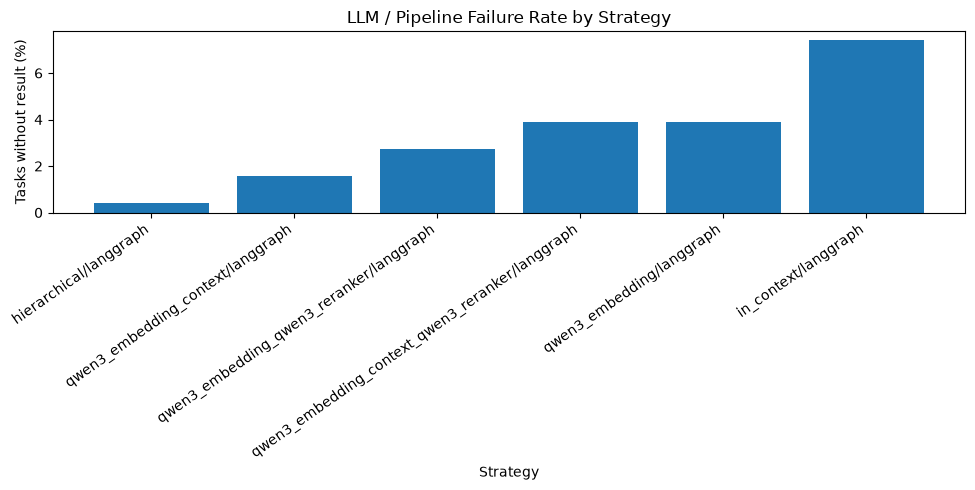

In [152]:
coverage_plot = strategy_summary.sort_values(
    "no_result_rate"
)

plt.figure(figsize=(10, 5))

plt.bar(
    coverage_plot["strategy"],
    coverage_plot["no_result_rate"] * 100
)

plt.ylabel("Tasks without result (%)")
plt.xlabel("Strategy")
plt.title("LLM / Pipeline Failure Rate by Strategy")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

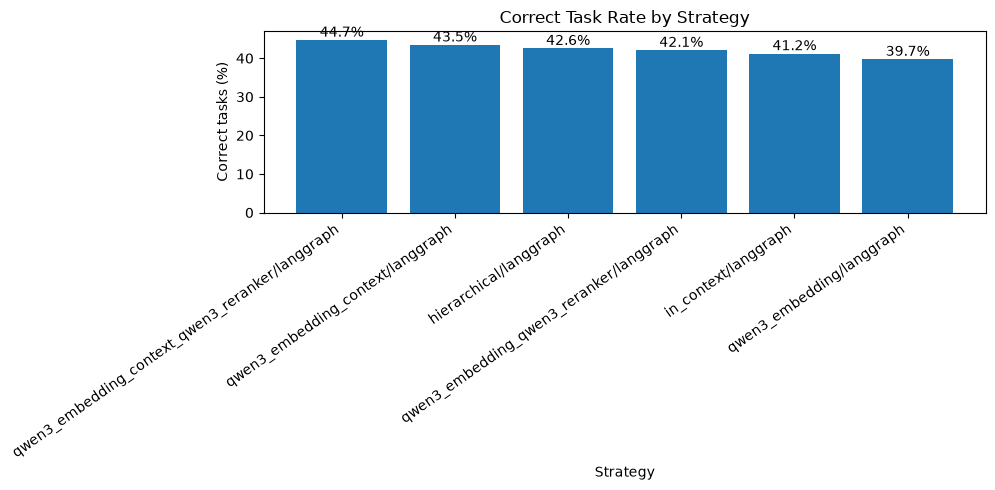

In [153]:
# ============================================================
# Correct task rate
# ============================================================

plot_df = strategy_summary.sort_values(
    "correct_rate",
    ascending=False
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["correct_rate"] * 100
)

plt.ylabel("Correct tasks (%)")
plt.xlabel("Strategy")
plt.title("Correct Task Rate by Strategy")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["correct_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

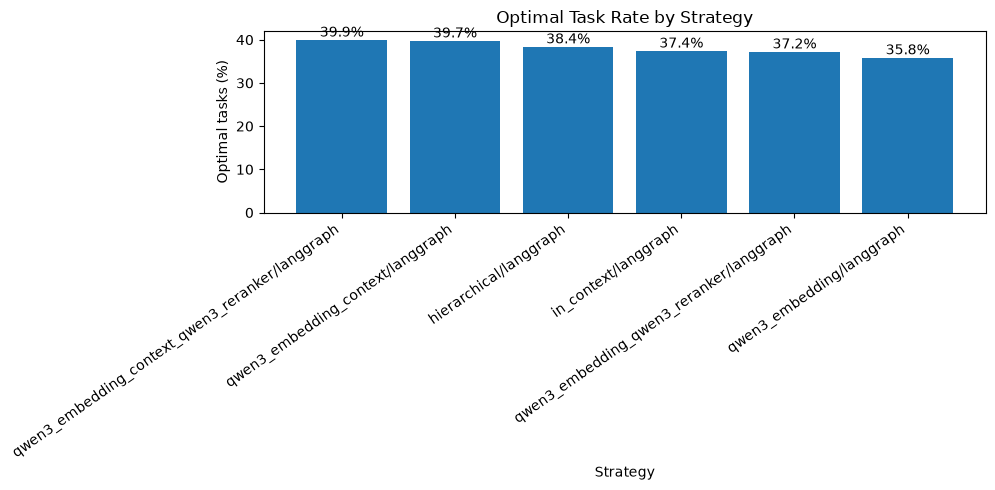

In [154]:
# ============================================================
# Optimal task rate
# ============================================================

plot_df = strategy_summary.sort_values(
    "optimal_rate",
    ascending=False
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["optimal_rate"] * 100
)

plt.ylabel("Optimal tasks (%)")
plt.xlabel("Strategy")
plt.title("Optimal Task Rate by Strategy")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["optimal_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

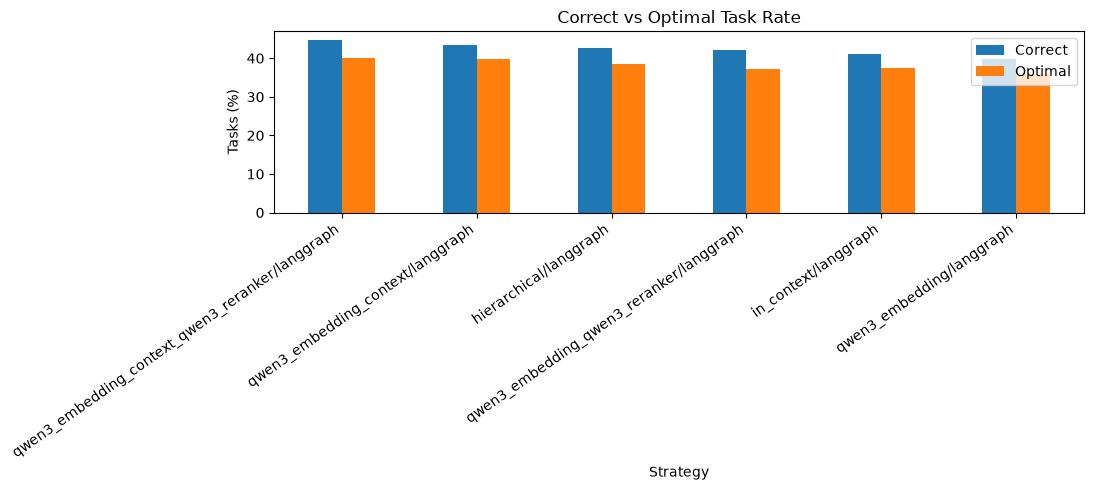

In [155]:
# ============================================================
# Correct vs optimal
# ============================================================

comparison = (
    strategy_summary[
        ["strategy", "correct_rate", "optimal_rate"]
    ]
    .set_index("strategy")
    * 100
)

comparison.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Tasks (%)")
plt.xlabel("Strategy")
plt.title("Correct vs Optimal Task Rate")

plt.xticks(rotation=35, ha="right")
plt.legend(["Correct", "Optimal"])

plt.tight_layout()
plt.show()

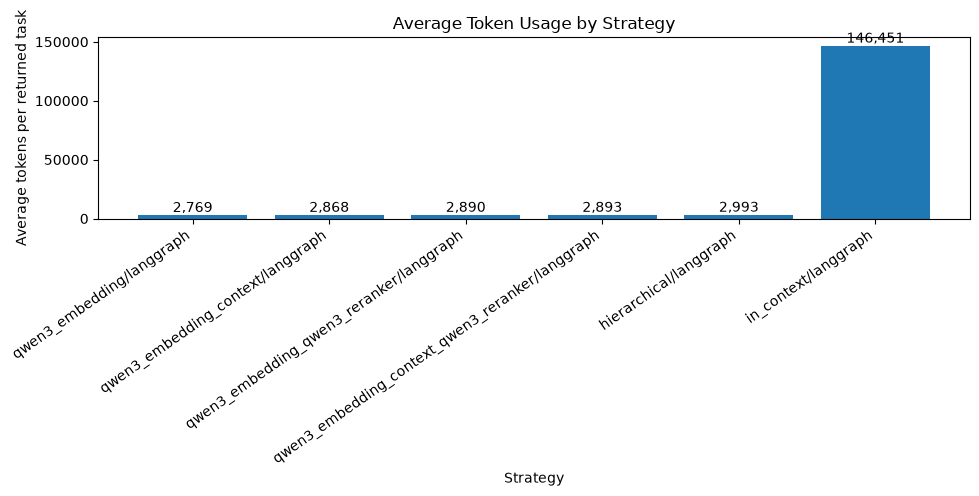

In [156]:
# ============================================================
# Average token usage
# ============================================================

token_summary = (
    task_df
    .groupby("strategy")["total_tokens"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    token_summary.index,
    token_summary.values
)

plt.ylabel("Average tokens per returned task")
plt.xlabel("Strategy")
plt.title("Average Token Usage by Strategy")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, token_summary.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

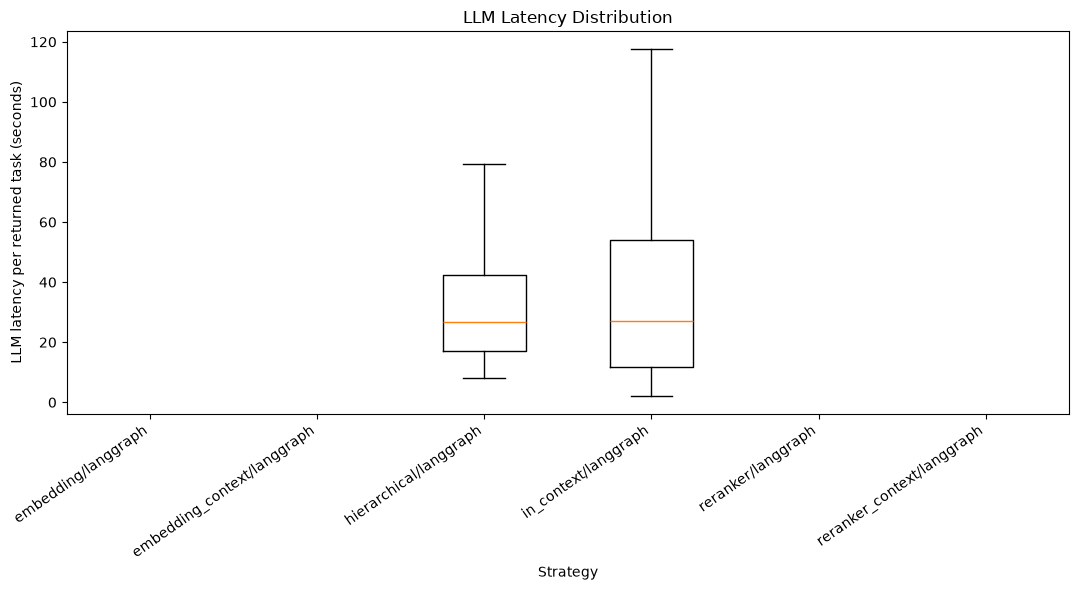

In [157]:
# ============================================================
# LLM latency distribution
# ============================================================

latency_data = [
    task_df.loc[
        task_df["strategy"] == strategy,
        "latency"
    ].dropna()
    for strategy in strategies
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    latency_data,
    tick_labels=strategies,
    showfliers=False
)

plt.ylabel("LLM latency per returned task (seconds)")
plt.xlabel("Strategy")
plt.title("LLM Latency Distribution")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

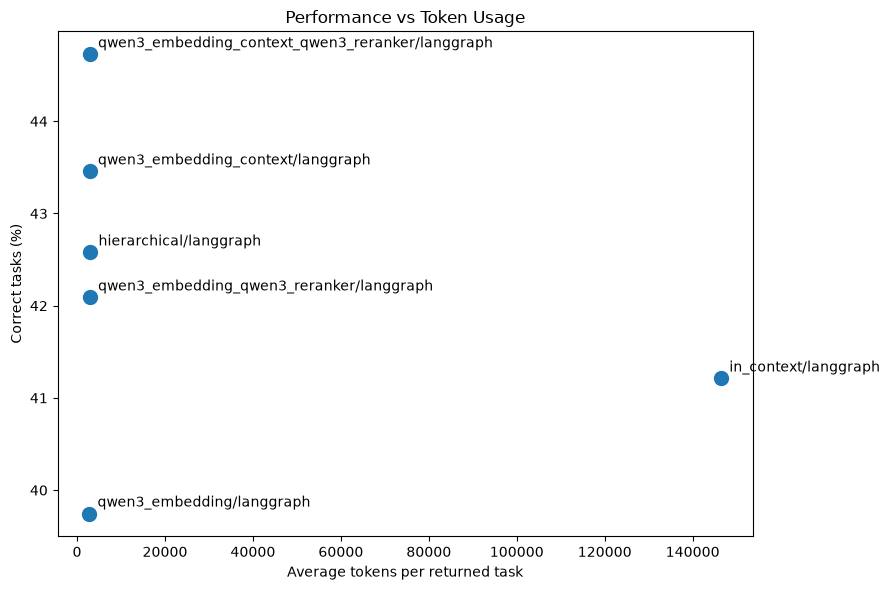

In [158]:
# ============================================================
# Accuracy vs token usage
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    strategy_summary["avg_total_tokens"],
    strategy_summary["correct_rate"] * 100,
    s=100
)

for _, row in strategy_summary.iterrows():

    plt.annotate(
        row["strategy"],
        (
            row["avg_total_tokens"],
            row["correct_rate"] * 100
        ),
        xytext=(6, 5),
        textcoords="offset points"
    )

plt.xlabel("Average tokens per returned task")
plt.ylabel("Correct tasks (%)")
plt.title("Performance vs Token Usage")

plt.tight_layout()
plt.show()

In [159]:
# ============================================================
# Task × Strategy correctness matrix
# ============================================================

correct_matrix = task_df.pivot_table(
    index=[
        "benchmark_task_number",
        "task_id",
        "task_idx"
    ],
    columns="strategy",
    values="correct",
    aggfunc="first"
)

# Should not normally be necessary now, but protects against
# missing strategy/task combinations.
correct_matrix = correct_matrix.fillna(False).astype(bool)

print("Shape:", correct_matrix.shape)

display(correct_matrix.head())

Shape: (1024, 6)


,,strategy,hierarchical/langgraph,in_context/langgraph,qwen3_embedding/langgraph,qwen3_embedding_context/langgraph,qwen3_embedding_context_qwen3_reranker/langgraph,qwen3_embedding_qwen3_reranker/langgraph
benchmark_task_number,task_id,task_idx,,,,,,
1,wild_tool_bench_0,0,True,False,False,True,True,True
2,wild_tool_bench_0,1,True,True,False,True,True,False
3,wild_tool_bench_0,2,False,False,False,False,False,False
4,wild_tool_bench_0,3,True,True,True,True,True,False
5,wild_tool_bench_1,0,True,True,True,True,True,True


In [160]:
# ============================================================
# Number of strategies solving each task
# ============================================================

task_analysis = correct_matrix.copy()

task_analysis["num_strategies_correct"] = (
    correct_matrix.sum(axis=1)
)

task_analysis["num_strategies_failed"] = (
    len(correct_matrix.columns)
    - task_analysis["num_strategies_correct"]
)

task_analysis["solved_by_any"] = (
    task_analysis["num_strategies_correct"] > 0
)

task_analysis["solved_by_all"] = (
    task_analysis["num_strategies_correct"]
    == len(correct_matrix.columns)
)

task_analysis["failed_by_all"] = (
    task_analysis["num_strategies_correct"] == 0
)

In [161]:
difficulty_distribution = (
    task_analysis["num_strategies_correct"]
    .value_counts()
    .sort_index()
)

display(difficulty_distribution)

num_strategies_correct
0    337
1    121
2     90
3     83
4    105
5     99
6    189
Name: count, dtype: int64

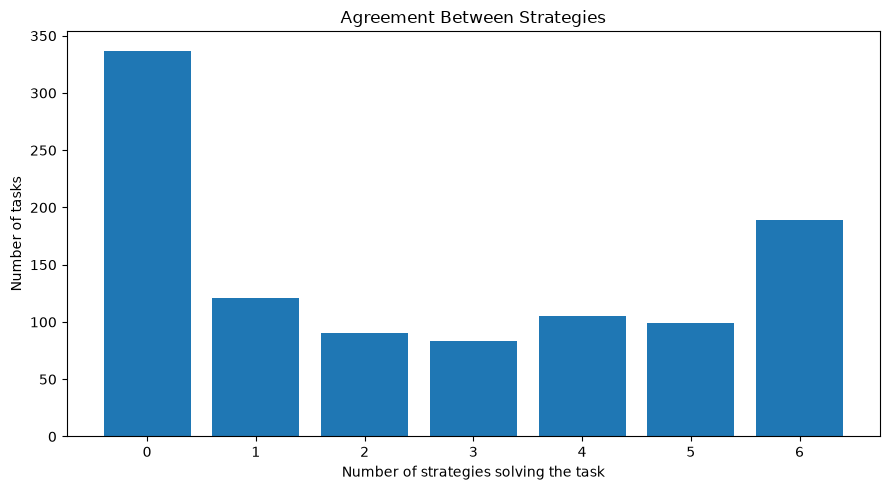

In [162]:
plt.figure(figsize=(9, 5))

plt.bar(
    difficulty_distribution.index,
    difficulty_distribution.values
)

plt.xlabel("Number of strategies solving the task")
plt.ylabel("Number of tasks")
plt.title("Agreement Between Strategies")

plt.xticks(range(len(correct_matrix.columns) + 1))

plt.tight_layout()
plt.show()

In [163]:
# ============================================================
# Overall overlap statistics
# ============================================================

n_tasks = len(task_analysis)

n_all_correct = task_analysis["solved_by_all"].sum()
n_all_failed = task_analysis["failed_by_all"].sum()
n_any_correct = task_analysis["solved_by_any"].sum()

n_exactly_one = (
    task_analysis["num_strategies_correct"] == 1
).sum()

overlap_summary = pd.DataFrame({
    "category": [
        "Solved by all strategies",
        "Solved by at least one strategy",
        "Solved by exactly one strategy",
        "Failed by all strategies",
    ],
    "tasks": [
        n_all_correct,
        n_any_correct,
        n_exactly_one,
        n_all_failed,
    ]
})

overlap_summary["rate"] = (
    overlap_summary["tasks"] / n_tasks
)

display(
    overlap_summary.style.format({
        "rate": "{:.1%}"
    })
)

,category,tasks,rate
0,Solved by all strategies,189,18.5%
1,Solved by at least one strategy,687,67.1%
2,Solved by exactly one strategy,121,11.8%
3,Failed by all strategies,337,32.9%


In [164]:
# ============================================================
# Unique wins per strategy
# ============================================================

unique_wins = {}

for strategy in correct_matrix.columns:

    strategy_correct = correct_matrix[strategy]

    other_strategies = correct_matrix.columns.drop(strategy)

    others_correct = (
        correct_matrix[other_strategies]
        .any(axis=1)
    )

    unique_mask = (
        strategy_correct
        & ~others_correct
    )

    unique_wins[strategy] = unique_mask.sum()


unique_wins_df = (
    pd.DataFrame.from_dict(
        unique_wins,
        orient="index",
        columns=["unique_wins"]
    )
    .sort_values(
        "unique_wins",
        ascending=False
    )
)

unique_wins_df

,unique_wins
hierarchical/langgraph,34
in_context/langgraph,23
qwen3_embedding_qwen3_reranker/langgraph,23
qwen3_embedding_context_qwen3_reranker/langgraph,19
qwen3_embedding_context/langgraph,15
qwen3_embedding/langgraph,7


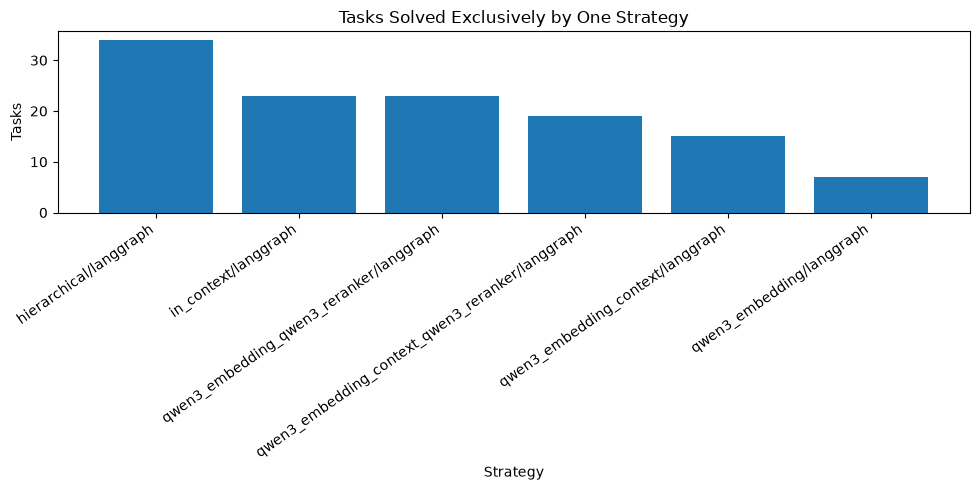

In [165]:
plt.figure(figsize=(10, 5))

plt.bar(
    unique_wins_df.index,
    unique_wins_df["unique_wins"]
)

plt.ylabel("Tasks")
plt.xlabel("Strategy")

plt.title(
    "Tasks Solved Exclusively by One Strategy"
)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [166]:
# ============================================================
# Identify unique-win tasks
# ============================================================

unique_win_rows = []

for strategy in correct_matrix.columns:

    others = correct_matrix.columns.drop(strategy)

    mask = (
        correct_matrix[strategy]
        & ~correct_matrix[others].any(axis=1)
    )

    for index in correct_matrix.index[mask]:

        benchmark_number, task_id, task_idx = index

        meta = task_metadata.get(
            (task_id, task_idx),
            {}
        )

        unique_win_rows.append({
            "strategy": strategy,
            "benchmark_task_number": benchmark_number,
            "task_id": task_id,
            "task_idx": task_idx,
            "task_type": meta.get("task_type"),
            "task_text": meta.get("task_text"),
        })


unique_win_tasks = pd.DataFrame(unique_win_rows)

display(unique_win_tasks)

,strategy,benchmark_task_number,task_id,task_idx,task_type,task_text
0,hierarchical/langgraph,28,wild_tool_bench_6,3,Clarify,I also want to buy something else
1,hierarchical/langgraph,234,wild_tool_bench_58,1,Clarify,I want to know the current traffic conditions.
2,hierarchical/langgraph,276,wild_tool_bench_68,3,Parallel Multi-Tool,The detailed information of the IP addresses i...
3,hierarchical/langgraph,335,wild_tool_bench_83,2,Clarify,Can you help me get the link to the songs in t...
4,hierarchical/langgraph,341,wild_tool_bench_85,0,Parallel Multi-Tool,I want to find a recently popular song named '...
...,...,...,...,...,...,...
116,qwen3_embedding_qwen3_reranker/langgraph,803,wild_tool_bench_200,2,Single-Tool,How has Adolis García performed this season?
117,qwen3_embedding_qwen3_reranker/langgraph,809,wild_tool_bench_202,0,Chat,What are the categories of popular books and t...
118,qwen3_embedding_qwen3_reranker/langgraph,879,wild_tool_bench_219,2,Chat,Are there any good beers to recommend here and...
119,qwen3_embedding_qwen3_reranker/langgraph,896,wild_tool_bench_223,3,Single-Tool,Verify whether the IP I mentioned earlier is a...


In [167]:
display(
    unique_win_tasks.groupby(
        ["strategy", "task_type"]
    )
    .size()
    .unstack(fill_value=0)
)

task_type,Chat,Clarify,Mixed Multi-Tool,Parallel Multi-Tool,Sequential Multi-Tool,Single-Tool
strategy,,,,,,
hierarchical/langgraph,7,6,4,7,0,10
in_context/langgraph,0,10,0,4,0,9
qwen3_embedding/langgraph,0,3,1,2,0,1
qwen3_embedding_context/langgraph,1,8,2,3,0,1
qwen3_embedding_context_qwen3_reranker/langgraph,0,9,1,3,1,5
qwen3_embedding_qwen3_reranker/langgraph,2,6,4,6,0,5


In [168]:
# ============================================================
# Tasks failed by every strategy
# ============================================================

consensus_failure_mask = (
    correct_matrix.sum(axis=1) == 0
)

consensus_failure_indices = (
    correct_matrix.index[
        consensus_failure_mask
    ]
)

consensus_failure_rows = []

for index in consensus_failure_indices:

    benchmark_number, task_id, task_idx = index

    meta = task_metadata.get(
        (task_id, task_idx),
        {}
    )

    consensus_failure_rows.append({
        "benchmark_task_number": benchmark_number,
        "task_id": task_id,
        "task_idx": task_idx,
        "task_type": meta.get("task_type"),
        "task_text": meta.get("task_text"),
    })


consensus_failures = pd.DataFrame(
    consensus_failure_rows
)

print(
    f"{len(consensus_failures)} / {len(correct_matrix)} "
    f"tasks failed by every strategy "
    f"({len(consensus_failures) / len(correct_matrix):.1%})"
)

display(consensus_failures.head(20))

337 / 1024 tasks failed by every strategy (32.9%)


,benchmark_task_number,task_id,task_idx,task_type,task_text
0,3,wild_tool_bench_0,2,Mixed Multi-Tool,"Check the air quality as well. If it's good, t..."
1,8,wild_tool_bench_1,3,Clarify,I want to know what courses related to one of ...
2,10,wild_tool_bench_2,1,Single-Tool,Create another new transaction record with an ...
3,15,wild_tool_bench_3,2,Clarify,I have a visitor who is from one of the above ...
4,19,wild_tool_bench_4,2,Parallel Multi-Tool,"Okay, I've been researching users these days. ..."
5,20,wild_tool_bench_4,3,Clarify,I need to set up two-factor authentication for...
6,32,wild_tool_bench_7,3,Parallel Multi-Tool,I also want to know the information about an e...
7,40,wild_tool_bench_9,3,Mixed Multi-Tool,Get the content of the other articles above fo...
8,52,wild_tool_bench_12,3,Mixed Multi-Tool,Which countries' sports-related datasets were ...
9,55,wild_tool_bench_13,2,Parallel Multi-Tool,The detailed information of the two most frequ...


In [169]:
# ============================================================
# Consensus failures by task type
# ============================================================

all_task_types = (
    task_df[
        [
            "benchmark_task_number",
            "task_type"
        ]
    ]
    .drop_duplicates()
    ["task_type"]
    .value_counts()
)

failure_types = (
    consensus_failures["task_type"]
    .value_counts()
)

failure_type_analysis = pd.DataFrame({
    "total_tasks": all_task_types,
    "consensus_failures": failure_types
}).fillna(0)

failure_type_analysis["failure_rate"] = (
    failure_type_analysis["consensus_failures"]
    / failure_type_analysis["total_tasks"]
)

failure_type_analysis = (
    failure_type_analysis
    .sort_values(
        "failure_rate",
        ascending=False
    )
)

display(
    failure_type_analysis.style.format({
        "failure_rate": "{:.1%}"
    })
)

,total_tasks,consensus_failures,failure_rate
task_type,,,
Mixed Multi-Tool,84,66,78.6%
Sequential Multi-Tool,16,9,56.2%
Clarify,256,121,47.3%
Parallel Multi-Tool,156,72,46.2%
Single-Tool,256,57,22.3%
Chat,256,12,4.7%


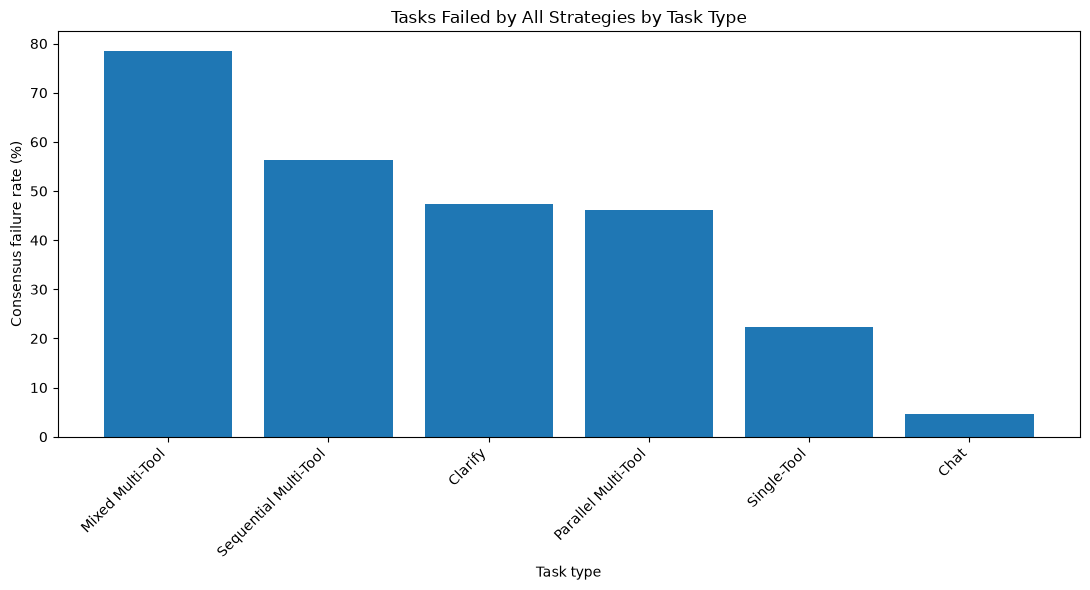

In [170]:
plt.figure(figsize=(11, 6))

plt.bar(
    failure_type_analysis.index,
    failure_type_analysis["failure_rate"] * 100
)

plt.ylabel("Consensus failure rate (%)")
plt.xlabel("Task type")

plt.title(
    "Tasks Failed by All Strategies by Task Type"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [171]:
# ============================================================
# Pairwise Jaccard similarity of solved tasks
# ============================================================

strategies = list(correct_matrix.columns)

jaccard = pd.DataFrame(
    index=strategies,
    columns=strategies,
    dtype=float
)

for strategy_a in strategies:

    for strategy_b in strategies:

        a = correct_matrix[strategy_a]
        b = correct_matrix[strategy_b]

        intersection = (a & b).sum()
        union = (a | b).sum()

        jaccard.loc[
            strategy_a,
            strategy_b
        ] = (
            intersection / union
            if union > 0
            else np.nan
        )


display(
    jaccard.style.format("{:.3f}")
)

,hierarchical/langgraph,in_context/langgraph,qwen3_embedding/langgraph,qwen3_embedding_context/langgraph,qwen3_embedding_context_qwen3_reranker/langgraph,qwen3_embedding_qwen3_reranker/langgraph
hierarchical/langgraph,1.000,0.574,0.558,0.559,0.555,0.548
in_context/langgraph,0.574,1.000,0.544,0.579,0.555,0.502
qwen3_embedding/langgraph,0.558,0.544,1.000,0.623,0.617,0.686
qwen3_embedding_context/langgraph,0.559,0.579,0.623,1.000,0.707,0.570
qwen3_embedding_context_qwen3_reranker/langgraph,0.555,0.555,0.617,0.707,1.000,0.613
qwen3_embedding_qwen3_reranker/langgraph,0.548,0.502,0.686,0.570,0.613,1.000


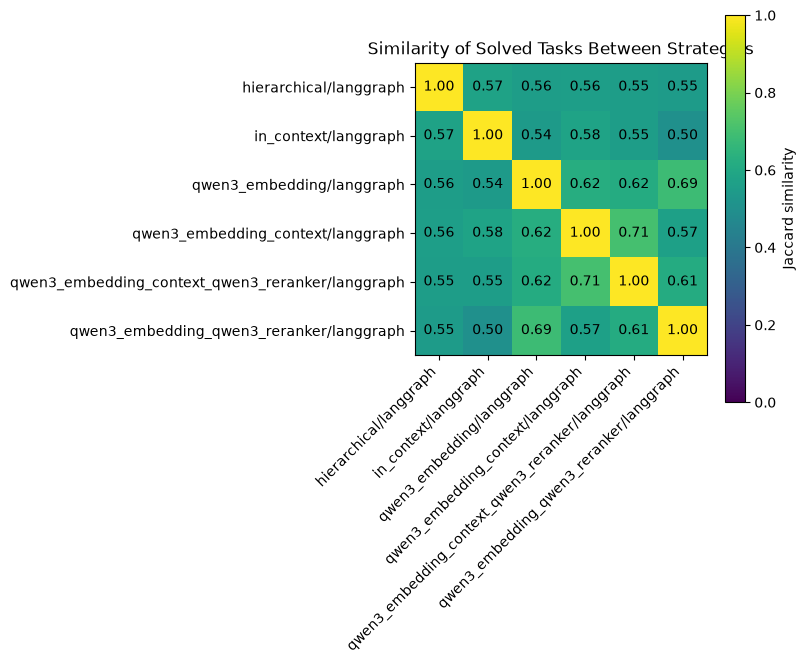

In [172]:
# ============================================================
# Jaccard similarity heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    jaccard.values,
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(strategies))
)

ax.set_yticks(
    range(len(strategies))
)

ax.set_xticklabels(
    strategies,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    strategies
)

for i in range(len(strategies)):
    for j in range(len(strategies)):

        ax.text(
            j,
            i,
            f"{jaccard.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    label="Jaccard similarity"
)

plt.title(
    "Similarity of Solved Tasks Between Strategies"
)

plt.tight_layout()
plt.show()

In [173]:
# ============================================================
# Build selection-level dataframe
# ============================================================

selection_rows_all = []

for strategy, files in runs.items():

    selection_file = files.get("selection")

    if selection_file is None or not selection_file.exists():
        continue

    selection_rows = read_jsonl(selection_file)

    for row in selection_rows:

        selected = safe_float(
            row.get("selected_tools_count")
        )

        available = safe_float(
            row.get("available_tools_count")
        )

        reduction = None

        if (
            selected is not None
            and available is not None
            and available > 0
        ):
            reduction = 1 - selected / available

        selection_rows_all.append({
            "strategy": strategy,

            "task_id": str(
                row.get("test_entry_id", "")
            ),

            "task_idx": row.get("task_idx"),

            "selected_tools":
                selected,

            "available_tools":
                available,

            "selection_reduction":
                reduction,

            "zero_selected":
                selected == 0
                if selected is not None
                else False,
        })


selection_df = pd.DataFrame(
    selection_rows_all
)

print(selection_df.shape)

display(selection_df.head())

(12145, 7)


,strategy,task_id,task_idx,selected_tools,available_tools,selection_reduction,zero_selected
0,hierarchical/langgraph,wild_tool_bench_0,0.0,9.0,1283.0,0.992985,False
1,hierarchical/langgraph,wild_tool_bench_0,1.0,2.0,1283.0,0.998441,False
2,hierarchical/langgraph,wild_tool_bench_0,2.0,2.0,1283.0,0.998441,False
3,hierarchical/langgraph,wild_tool_bench_0,3.0,1.0,1283.0,0.999221,False
4,hierarchical/langgraph,wild_tool_bench_1,0.0,1.0,1283.0,0.999221,False


In [174]:
# ============================================================
# Selection summary
# ============================================================

selection_summary = (
    selection_df
    .groupby("strategy")
    .agg(
        selection_calls=(
            "selected_tools",
            "size"
        ),

        avg_selected_tools=(
            "selected_tools",
            "mean"
        ),

        median_selected_tools=(
            "selected_tools",
            "median"
        ),

        avg_available_tools=(
            "available_tools",
            "mean"
        ),

        avg_reduction=(
            "selection_reduction",
            "mean"
        ),

        zero_selections=(
            "zero_selected",
            "sum"
        ),
    )
    .reset_index()
)

selection_summary["zero_selection_rate"] = (
    selection_summary["zero_selections"]
    / selection_summary["selection_calls"]
)

display(
    selection_summary.style.format({
        "avg_selected_tools": "{:.1f}",
        "median_selected_tools": "{:.1f}",
        "avg_available_tools": "{:.1f}",
        "avg_reduction": "{:.1%}",
        "zero_selection_rate": "{:.1%}",
    })
)

,strategy,selection_calls,avg_selected_tools,median_selected_tools,avg_available_tools,avg_reduction,zero_selections,zero_selection_rate
0,hierarchical/langgraph,1021,5.4,3.0,1283.0,99.6%,24,2.4%
1,in_context/langgraph,1,1283.0,1283.0,1283.0,0.0%,0,0.0%
2,qwen3_embedding/langgraph,1894,5.0,5.0,1283.0,99.6%,0,0.0%
3,qwen3_embedding_context/langgraph,1729,5.0,5.0,1283.0,99.6%,0,0.0%
4,qwen3_embedding_context_qwen3_reranker/langgraph,3536,12.5,12.5,643.9,40.5%,0,0.0%
5,qwen3_embedding_qwen3_reranker/langgraph,3964,13.3,20.0,714.2,46.9%,0,0.0%


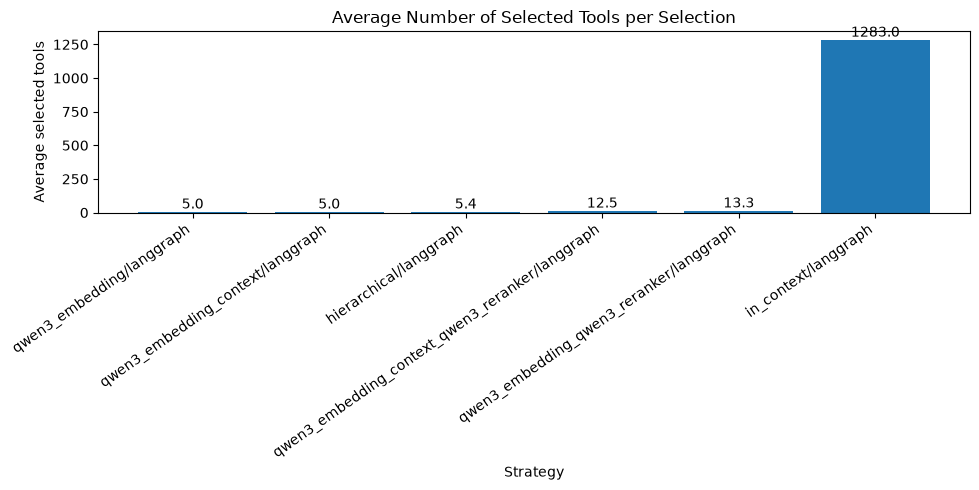

In [175]:
plot_df = (
    selection_summary
    .sort_values("avg_selected_tools")
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["avg_selected_tools"]
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Average Number of Selected Tools per Selection")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(
    bars,
    plot_df["avg_selected_tools"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [179]:
# ============================================================
# Aggregate selection information per task
# ============================================================

selection_per_task = (
    selection_df
    .groupby(
        ["strategy", "task_id", "task_idx"]
    )
    .agg(
        avg_selected_tools=(
            "selected_tools",
            "mean"
        ),

        max_selected_tools=(
            "selected_tools",
            "max"
        ),

        avg_available_tools=(
            "available_tools",
            "mean"
        ),

        avg_selection_reduction=(
            "selection_reduction",
            "mean"
        ),

        num_selection_calls=(
            "selected_tools",
            "size"
        ),
    )
    .reset_index()
)

In [180]:
selection_task_df = task_df.merge(
    selection_per_task,
    on=[
        "strategy",
        "task_id",
        "task_idx"
    ],
    how="left"
)

In [181]:
selected_vs_correct = (
    selection_task_df
    .dropna(subset=["avg_selected_tools"])
    .groupby(
        ["strategy", "correct"]
    )
    ["avg_selected_tools"]
    .mean()
    .unstack()
)

selected_vs_correct.columns = [
    "incorrect",
    "correct"
]

display(selected_vs_correct)

,incorrect,correct
strategy,,
hierarchical/langgraph,5.258120,5.541284
qwen3_embedding/langgraph,5.000000,5.000000
qwen3_embedding_context/langgraph,5.000000,5.000000
qwen3_embedding_context_qwen3_reranker/langgraph,12.500000,12.500000
qwen3_embedding_qwen3_reranker/langgraph,12.917083,13.045552


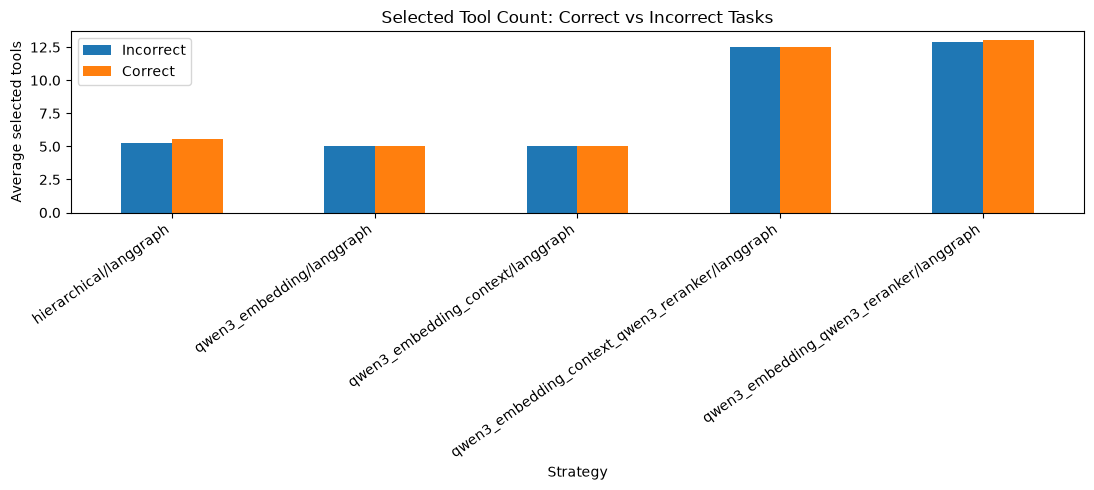

In [182]:
selected_vs_correct.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Selected Tool Count: Correct vs Incorrect Tasks")

plt.xticks(rotation=35, ha="right")

plt.legend([
    "Incorrect",
    "Correct"
])

plt.tight_layout()
plt.show()

In [183]:
selected_vs_optimal = (
    selection_task_df
    .dropna(subset=["avg_selected_tools"])
    .groupby(
        ["strategy", "optimal"]
    )
    ["avg_selected_tools"]
    .mean()
    .unstack()
)

selected_vs_optimal.columns = [
    "not_optimal",
    "optimal"
]

display(selected_vs_optimal)

,not_optimal,optimal
strategy,,
hierarchical/langgraph,5.154459,5.737913
qwen3_embedding/langgraph,5.000000,5.000000
qwen3_embedding_context/langgraph,5.000000,5.000000
qwen3_embedding_context_qwen3_reranker/langgraph,12.500000,12.500000
qwen3_embedding_qwen3_reranker/langgraph,12.907029,13.079115


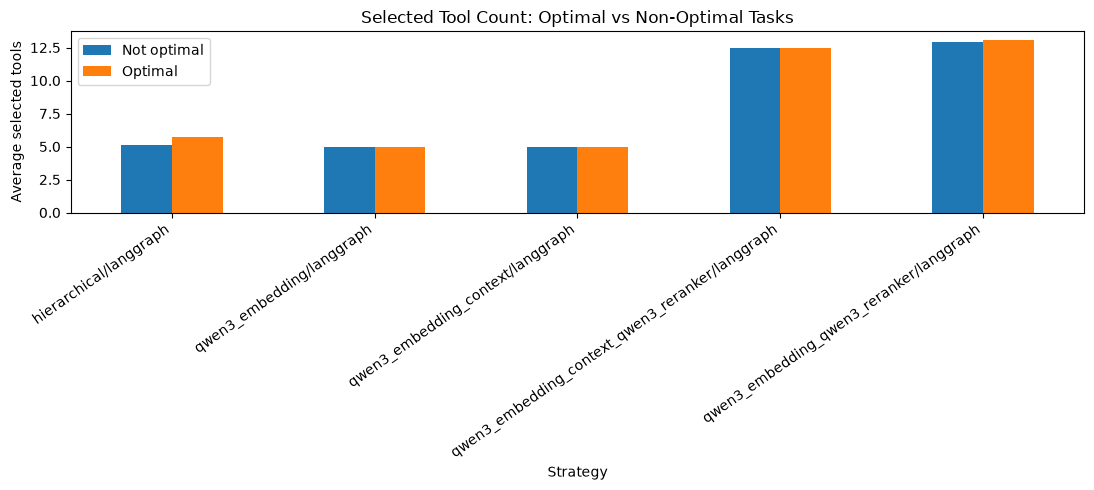

In [184]:
selected_vs_optimal.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Average selected tools")
plt.xlabel("Strategy")
plt.title("Selected Tool Count: Optimal vs Non-Optimal Tasks")

plt.xticks(rotation=35, ha="right")

plt.legend([
    "Not optimal",
    "Optimal"
])

plt.tight_layout()
plt.show()

In [185]:
selection_task_df["selection_size_bucket"] = pd.cut(
    selection_task_df["avg_selected_tools"],
    bins=[
        0,
        5,
        10,
        20,
        50,
        100,
        float("inf")
    ],
    labels=[
        "1–5",
        "6–10",
        "11–20",
        "21–50",
        "51–100",
        "100+"
    ],
    include_lowest=True
)

In [186]:
bucket_performance = (
    selection_task_df
    .dropna(subset=["selection_size_bucket"])
    .groupby(
        ["strategy", "selection_size_bucket"],
        observed=True
    )
    .agg(
        tasks=("correct", "size"),
        correct_rate=("correct", "mean"),
        optimal_rate=("optimal", "mean"),
        avg_pipeline_tokens=(
            "pipeline_total_tokens",
            "mean"
        ),
    )
    .reset_index()
)

display(bucket_performance)

,strategy,selection_size_bucket,tasks,correct_rate,optimal_rate,avg_pipeline_tokens
0,hierarchical/langgraph,1–5,584,0.412671,0.356164,2586.917808
1,hierarchical/langgraph,6–10,427,0.442623,0.419204,3499.871194
2,hierarchical/langgraph,11–20,4,0.500000,0.500000,5083.250000
3,hierarchical/langgraph,21–50,6,0.666667,0.666667,4537.166667
4,qwen3_embedding/langgraph,1–5,1010,0.402970,0.363366,2697.501980
5,qwen3_embedding_context/langgraph,1–5,1017,0.437561,0.400197,2842.543756
6,qwen3_embedding_context_qwen3_reranker/langgraph,11–20,1009,0.453915,0.405352,2821.167493
7,qwen3_embedding_qwen3_reranker/langgraph,11–20,1014,0.425049,0.375740,2839.050296


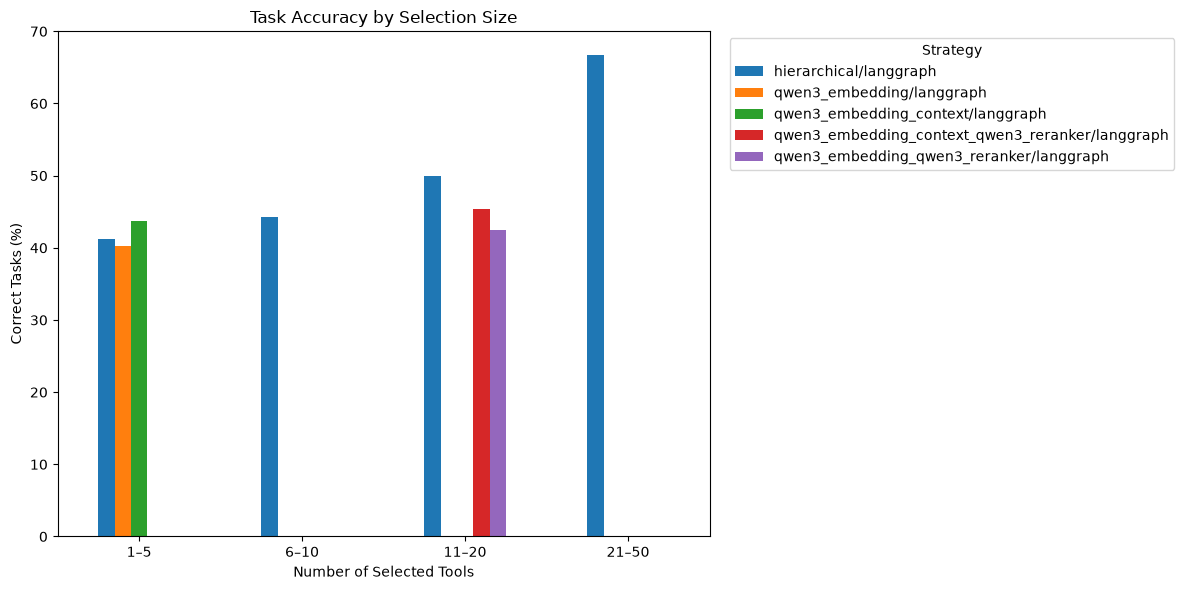

In [188]:
# ============================================================
# Plot: Accuracy by selected tool count
# ============================================================

accuracy_pivot = bucket_accuracy.pivot(
    index="selection_size_bucket",
    columns="strategy",
    values="accuracy_pct"
)

accuracy_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Number of Selected Tools")
plt.ylabel("Correct Tasks (%)")
plt.title("Task Accuracy by Selection Size")

plt.xticks(rotation=0)

plt.legend(
    title="Strategy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Section: Official `eval_runner.py` Scoring (`score/` directory)

The cells above analyze the raw `result/` folder with a hand-rolled accuracy
calculation. The cells below instead load the **official** metrics produced by
`wtb/eval_runner.py` (the `Wild-Tool-Bench_metric.json` files under `score/`),
which is the same scoring logic used for the leaderboard (task/session
accuracy, per task-type accuracy, and the optimal-tool-selection rate).

In [22]:
# ============================================================
# Discover all official score runs (produced by eval_runner.py)
# ============================================================

SCORE_ROOT = PROJECT_ROOT / "score"


def read_json(path: Path):
    """Read a single JSON object from disk, or None if missing."""

    if not path.exists():
        return None

    with open(path, encoding="utf-8") as f:
        return json.load(f)


def discover_score_runs(score_root: Path):
    """
    Discover every scored strategy under `score/`.

    Returns
    -------
    dict

    {
        "20B_in_context/langgraph": {
            "metric": Path(...),
            "score": Path(...),
        },
        ...
    }
    """

    runs = {}

    if not score_root.exists():
        return runs

    for metric_file in sorted(score_root.rglob("Wild-Tool-Bench_metric.json")):

        run_name = metric_file.parent.relative_to(score_root).as_posix()

        runs[run_name] = {
            "metric": metric_file,
            "score": metric_file.with_name("Wild-Tool-Bench_score.jsonl"),
        }

    return runs


score_runs = discover_score_runs(SCORE_ROOT)

print(f"Found {len(score_runs)} scored strategies under {SCORE_ROOT}\n")

for name, files in score_runs.items():
    print("=" * 60)
    print(name)

    for key, path in files.items():
        print(f"  {key:<10} {path.exists()}   {path}")


Found 8 scored strategies under /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score

120B_embedding/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_embedding/langgraph/Wild-Tool-Bench_score.jsonl
120B_in_context/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_in_context/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_in_context/langgraph/Wild-Tool-Bench_score.jsonl
20B_embedding/langgraph
  metric     True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/20B_embedding/langgraph/Wild-Tool-Bench_metric.json
  score      True   /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/20B_embedding/langgraph/Wild-Tool-Bench_score.jsonl
20B_embedding_context/langgraph
  

In [23]:
# ============================================================
# Load official metric.json files and build a summary table
# ============================================================

TASK_TYPES = [
    "Single-Tool",
    "Multi-Tool",
    "Parallel Multi-Tool",
    "Sequential Multi-Tool",
    "Mixed Multi-Tool",
    "Clarify",
    "Chat",
]

score_metrics = {}

score_summary_rows = []

for run_name, files in score_runs.items():

    metric = read_json(files["metric"])

    if metric is None:
        continue

    score_metrics[run_name] = metric

    total_info = metric.get("total_info", {}) or {}
    task_info = total_info.get("task", {}) or {}
    session_info = total_info.get("session", {}) or {}

    optimal_info = metric.get("optimal_info", {}) or {}
    optimal_total = optimal_info.get("Total", {}) or {}

    row = {
        "strategy": run_name,
        "task_accuracy": task_info.get("accuracy"),
        "task_correct": task_info.get("correct_count"),
        "task_total": task_info.get("total_count"),
        "session_accuracy": session_info.get("accuracy"),
        "session_correct": session_info.get("correct_count"),
        "session_total": session_info.get("total_count"),
        "optimal_rate": optimal_total.get("accuracy"),
        "optimal_correct": optimal_total.get("correct_count"),
        "optimal_total": optimal_total.get("total_count"),
    }

    task_type_info = metric.get("task_type_info", {}) or {}

    for task_type in TASK_TYPES:
        stats = task_type_info.get(task_type, {}) or {}
        row[f"acc__{task_type}"] = stats.get("accuracy")

    score_summary_rows.append(row)

score_summary = pd.DataFrame(score_summary_rows).sort_values(
    "task_accuracy", ascending=False
)

score_summary


,strategy,task_accuracy,task_correct,task_total,session_accuracy,session_correct,session_total,optimal_rate,optimal_correct,optimal_total,acc__Single-Tool,acc__Multi-Tool,acc__Parallel Multi-Tool,acc__Sequential Multi-Tool,acc__Mixed Multi-Tool,acc__Clarify,acc__Chat
3,20B_embedding_context/langgraph,0.332031,340,1024,0.015625,4,256,0.012500,3,240,0.277344,0.074219,0.108974,0.0625,0.011905,0.191406,0.785156
1,120B_in_context/langgraph,0.331055,339,1024,0.019531,5,256,0.012500,3,240,0.296875,0.121094,0.179487,0.0625,0.023810,0.160156,0.746094
5,20B_embedding_reranker_context/langgraph,0.331055,339,1024,0.015625,4,256,0.012500,3,240,0.277344,0.101562,0.153846,0.0625,0.011905,0.179688,0.765625
6,20B_hierarchical/langgraph,0.319336,327,1024,0.015625,4,256,0.020833,5,240,0.250000,0.082031,0.128205,0.0625,0.000000,0.097656,0.847656
0,120B_embedding/langgraph,0.306641,314,1024,0.007812,2,256,0.012500,3,240,0.269531,0.113281,0.173077,0.0625,0.011905,0.128906,0.714844
4,20B_embedding_reranker/langgraph,0.295098,301,1020,0.011765,3,255,0.008403,2,238,0.247059,0.098425,0.142857,0.1250,0.011905,0.144531,0.690196
7,20B_in_context/langgraph,0.286133,293,1024,0.015625,4,256,0.008333,2,240,0.234375,0.062500,0.096154,0.0625,0.000000,0.132812,0.714844
2,20B_embedding/langgraph,0.280273,287,1024,0.011719,3,256,0.012500,3,240,0.234375,0.089844,0.134615,0.0625,0.011905,0.132812,0.664062


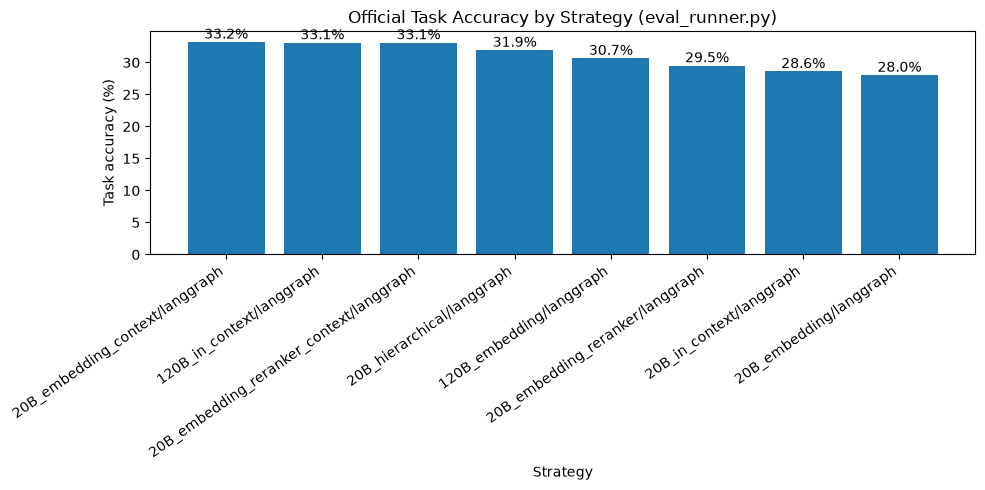

In [24]:
# ============================================================
# Plot: Official task accuracy by strategy
# ============================================================

plot_df = score_summary.sort_values("task_accuracy", ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["task_accuracy"] * 100
)

plt.ylabel("Task accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Task Accuracy by Strategy (eval_runner.py)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["task_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


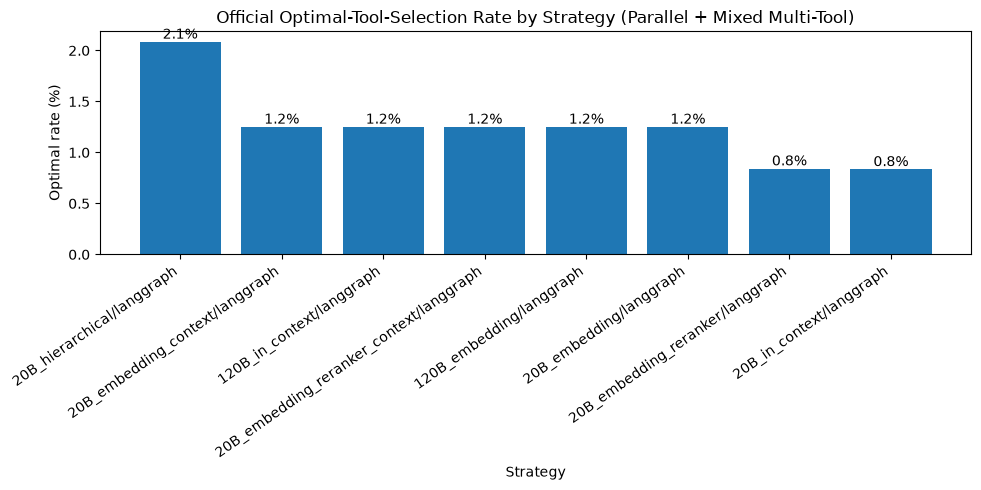

In [25]:
# ============================================================
# Plot: Official optimal-tool-selection rate by strategy
# ============================================================

plot_df = score_summary.dropna(subset=["optimal_rate"]).sort_values(
    "optimal_rate", ascending=False
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["optimal_rate"] * 100
)

plt.ylabel("Optimal rate (%)")
plt.xlabel("Strategy")
plt.title("Official Optimal-Tool-Selection Rate by Strategy (Parallel + Mixed Multi-Tool)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["optimal_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


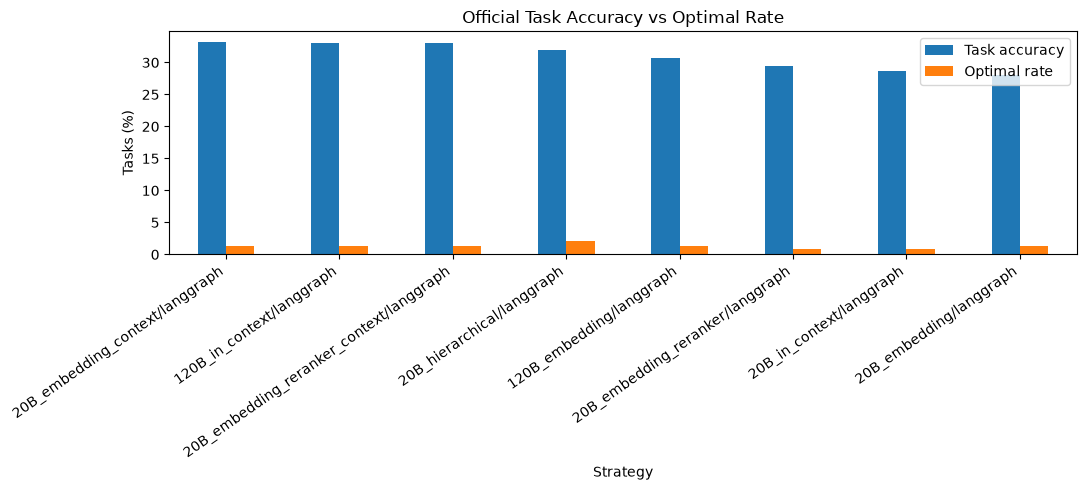

In [26]:
# ============================================================
# Plot: Official task accuracy vs optimal rate
# ============================================================

comparison = (
    score_summary[["strategy", "task_accuracy", "optimal_rate"]]
    .set_index("strategy")
    * 100
)

comparison.plot(kind="bar", figsize=(11, 5))

plt.ylabel("Tasks (%)")
plt.xlabel("Strategy")
plt.title("Official Task Accuracy vs Optimal Rate")

plt.xticks(rotation=35, ha="right")
plt.legend(["Task accuracy", "Optimal rate"])

plt.tight_layout()
plt.show()


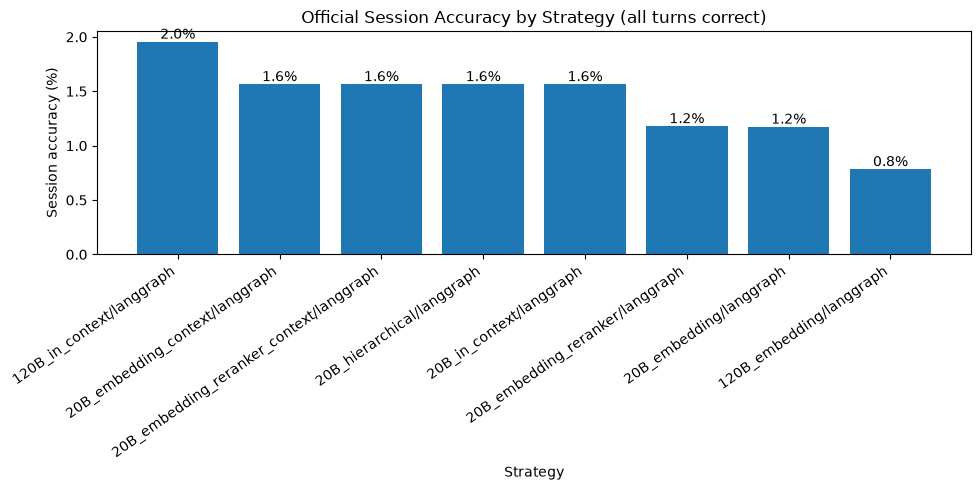

In [27]:
# ============================================================
# Plot: Official session (fully correct multi-turn) accuracy
# ============================================================

plot_df = score_summary.sort_values("session_accuracy", ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["strategy"],
    plot_df["session_accuracy"] * 100
)

plt.ylabel("Session accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Session Accuracy by Strategy (all turns correct)")

plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, plot_df["session_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


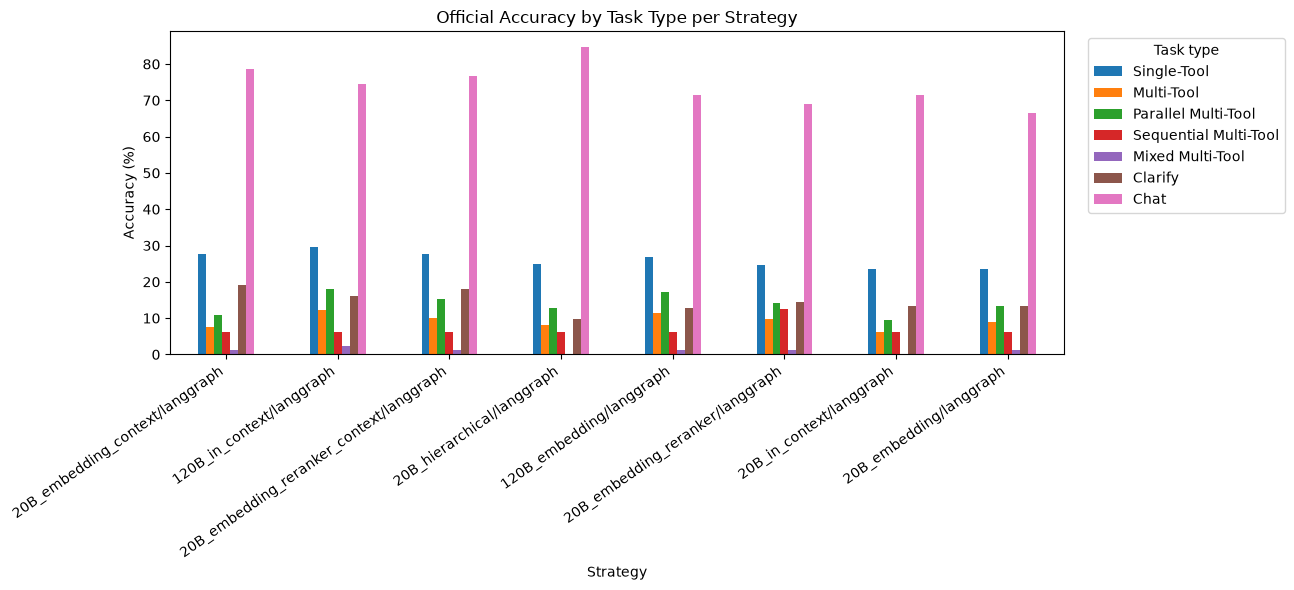

In [28]:
# ============================================================
# Plot: Official accuracy by task type, grouped by strategy
# ============================================================

task_type_cols = [f"acc__{t}" for t in TASK_TYPES]

task_type_pivot = (
    score_summary
    .set_index("strategy")[task_type_cols]
    .rename(columns=lambda c: c.replace("acc__", ""))
    * 100
)

task_type_pivot.plot(kind="bar", figsize=(13, 6))

plt.ylabel("Accuracy (%)")
plt.xlabel("Strategy")
plt.title("Official Accuracy by Task Type per Strategy")

plt.xticks(rotation=35, ha="right")

plt.legend(
    title="Task type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
